In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

set_seeds()

In [4]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_32_Weights.DEFAULT

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_32(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# 4. Change the classifier head
class_names = ['mutu1','mutu2','mutu3','mutu4','mutu5','mutu6']

set_seeds()

# Add dropout layer and weight decay
pretrained_vit.heads = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(in_features=768, out_features=len(class_names))
).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth
100%|██████████| 337M/337M [00:02<00:00, 160MB/s]  


In [5]:
!pip install torchinfo

In [6]:

from torchinfo import summary

# Print a summary using torchinfo (uncomment for actual output)
summary(model=pretrained_vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 6]              768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 7, 7]      (2,360,064)          False
├─Encoder (encoder)                                          [32, 50, 768]        [32, 50, 768]        38,400               False
│    └─Dropout (dropout)                                     [32, 50, 768]        [32, 50, 768]        --                   --
│    └─Sequential (layers)                                   [32, 50, 768]        [32, 50, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 50, 768]        [32, 50, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 50, 768]        [32, 

#### Notice how only the output layer is trainable, where as, all of the rest of the layers are untrainable (frozen).

In [7]:
# Setup directory paths to train and test images
train_dir = '/kaggle/input/arabica-beans/arabica_beans/50-50/train'
test_dir = '/kaggle/input/arabica-beans/arabica_beans/50-50/test'

Remember, if you're going to use a pretrained model, it's generally important to ensure your own custom data is transformed/formatted in the same way the data the original model was trained on.

In [8]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## And now we've got transforms ready, we can turn our images into DataLoaders using the create_dataloaders()

In [9]:
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):

  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)

  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

  return train_dataloader, test_dataloader, class_names

In [10]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, class_names = create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=pretrained_vit_transforms,
                                                                                                     batch_size=10) # Could increase if we had more samples, such as here: https://arxiv.org/abs/2205.01580 (there are other improvements there too...)


In [11]:
# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define your model, optimizer, and loss function
model = pretrained_vit
optimizer = torch.optim.AdamW(params=pretrained_vit.parameters(), lr=1e-3, weight_decay=3e-2)  # Add weight decay
loss_fn = torch.nn.CrossEntropyLoss()

# Set the number of epochs
epochs = 90

# Lists to store training and testing losses and accuracies
train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

# Training loop
for epoch in range(epochs):
    # Set model to train mode
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_dataloader_pretrained:
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Update training loss
        train_loss += loss.item() * images.size(0)

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Calculate average training loss and accuracy
    train_loss = train_loss / len(train_dataloader_pretrained.dataset)
    train_accuracy = correct_train / total_train

    # Append to history lists
    train_loss_history.append(train_loss)
    train_acc_history.append(train_accuracy)

    # Print training loss and accuracy
    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}')

    # Set model to evaluation mode
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    # Disable gradient calculation
    with torch.no_grad():
        for images, labels in test_dataloader_pretrained:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            # Update testing loss
            test_loss += loss.item() * images.size(0)

            # Calculate testing accuracy
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    # Calculate average testing loss and accuracy
    test_loss = test_loss / len(test_dataloader_pretrained.dataset)
    test_accuracy = correct_test / total_test

    # Append to history lists
    test_loss_history.append(test_loss)
    test_acc_history.append(test_accuracy)

    # Print testing loss and accuracy
    print(f'Epoch [{epoch+1}/{epochs}], Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}')


Epoch [1/90], Train Loss: 1.3173, Train Acc: 0.4700
Epoch [1/90], Test Loss: 0.9951, Test Acc: 0.6217
Epoch [2/90], Train Loss: 0.8813, Train Acc: 0.6750
Epoch [2/90], Test Loss: 0.8318, Test Acc: 0.6900
Epoch [3/90], Train Loss: 0.7424, Train Acc: 0.7333
Epoch [3/90], Test Loss: 0.7602, Test Acc: 0.7000
Epoch [4/90], Train Loss: 0.6783, Train Acc: 0.7467
Epoch [4/90], Test Loss: 0.7417, Test Acc: 0.6817
Epoch [5/90], Train Loss: 0.6151, Train Acc: 0.7917
Epoch [5/90], Test Loss: 0.7069, Test Acc: 0.6967
Epoch [6/90], Train Loss: 0.5885, Train Acc: 0.7917
Epoch [6/90], Test Loss: 0.6491, Test Acc: 0.7433
Epoch [7/90], Train Loss: 0.5281, Train Acc: 0.8250
Epoch [7/90], Test Loss: 0.6578, Test Acc: 0.7100
Epoch [8/90], Train Loss: 0.4977, Train Acc: 0.8333
Epoch [8/90], Test Loss: 0.6287, Test Acc: 0.7417
Epoch [9/90], Train Loss: 0.4829, Train Acc: 0.8467
Epoch [9/90], Test Loss: 0.6258, Test Acc: 0.7467
Epoch [10/90], Train Loss: 0.4498, Train Acc: 0.8450
Epoch [10/90], Test Loss: 0.6

pretrained ViT performed far better than our custom ViT model trained from scratch (in the same amount of time).


In [12]:
# Save the model instance
torch.save(pretrained_vit.state_dict(), 'vit-imgt-32(5050).pth')

In [13]:
import pandas as pd
from pandas import ExcelWriter

data = {
    'Train Loss': train_loss_history,
    'Train Acc': train_acc_history,
    'Test Loss': test_loss_history,
    'Test Acc': test_acc_history
}

df = pd.DataFrame(data)

with ExcelWriter('vit-imgt-32(5050).xlsx') as writer:
    df.to_excel(writer, sheet_name='All Data')
    train_loss_df = pd.DataFrame({'Epoch': train_loss_history, 'Train Loss': train_loss_history})
    train_loss_df.to_excel(writer, sheet_name='Training Loss')
    test_loss_df = pd.DataFrame({'Epoch': test_loss_history, 'Test Loss': test_loss_history})
    test_loss_df.to_excel(writer, sheet_name='Testing Loss')
    train_acc_df = pd.DataFrame({'Epoch': train_acc_history, 'Train Acc': train_acc_history})
    train_acc_df.to_excel(writer, sheet_name='Training Accuracy')
    test_acc_df = pd.DataFrame({'Epoch': test_acc_history, 'Test Acc': test_acc_history})
    test_acc_df.to_excel(writer, sheet_name='Testing Accuracy')

In [14]:
# Open a file for writing in append mode
with open('vit-imgt-32(5050).txt', 'a') as f:
    # Write headers to the file
    f.write('Epoch,Train Loss,Train Acc,Test Loss,Test Acc\n')

    # Loop over the number of epochs
    for epoch in range(epochs):
        # Calculate training loss and accuracy
        train_loss = train_loss_history[epoch]
        train_accuracy = train_acc_history[epoch]

        # Calculate testing loss and accuracy
        test_loss = test_loss_history[epoch]
        test_accuracy = test_acc_history[epoch]

        # Write the history to the file
        f.write(f'{epoch+1},{train_loss:.4f},{train_accuracy:.4f},{test_loss:.4f},{test_accuracy:.4f}\n')

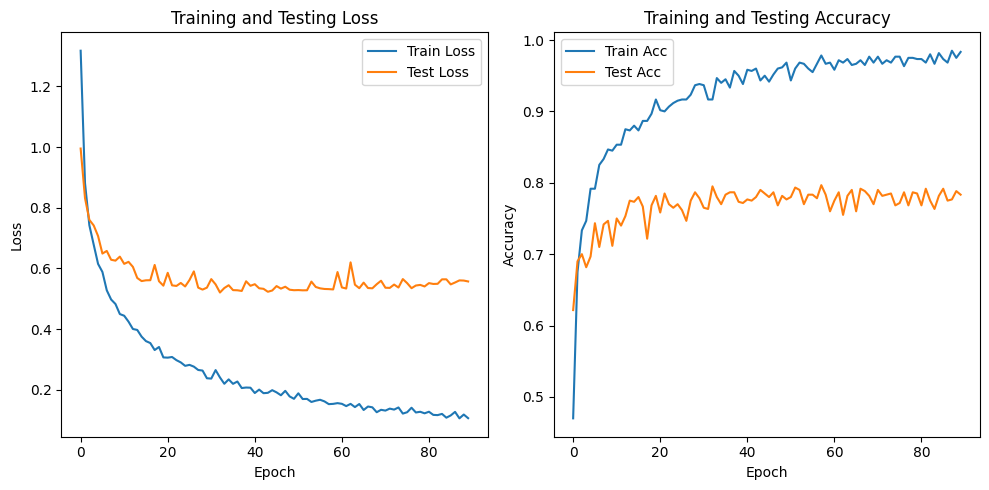

In [15]:
# Plot the training and testing loss and accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Acc')
plt.plot(test_acc_history, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.legend()

plt.tight_layout()

# Save the plot
plt.savefig('vit-imgt-32(5050).png')

plt.show()

# Let's make Prediction:

In [16]:
m1 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu1/1T-01.jpg"
m2 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu2/2H-06.jpg"
m3 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu3/3I-03.jpg"
m4 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu4/4J-08.jpg"
m5 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu5/5M-07.jpg"
m6 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu6/6B-05.jpg"

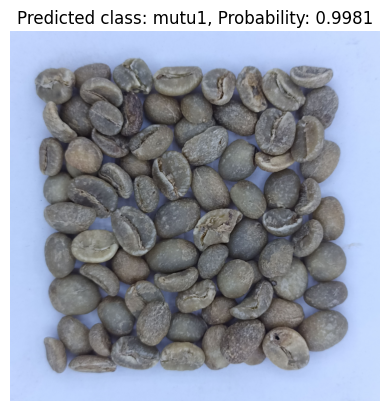

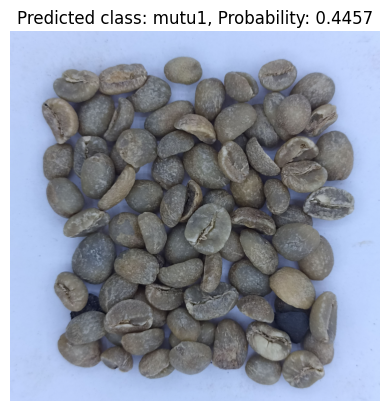

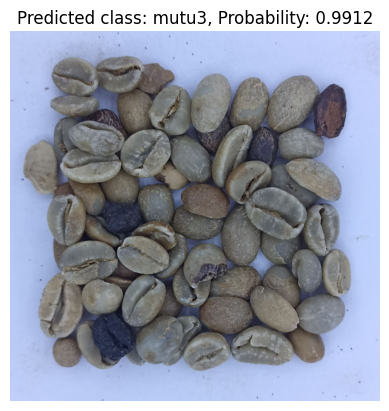

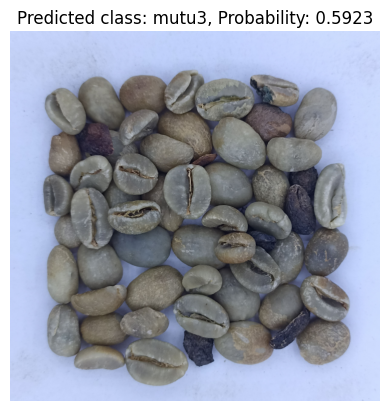

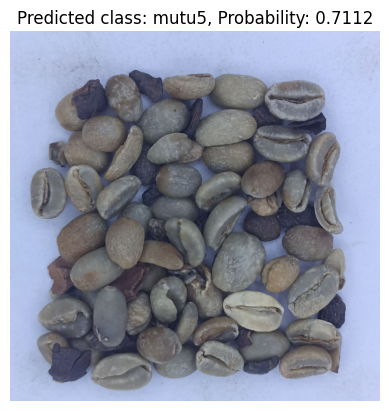

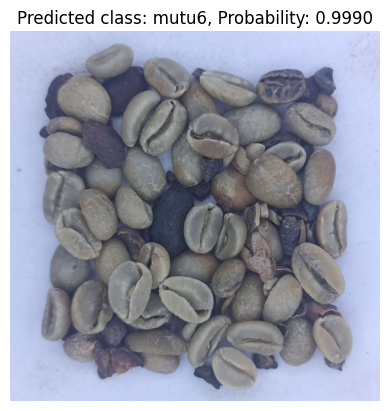

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_image(image_path, model, class_names):
    # Load the image
    image = Image.open(image_path)

    # Define transformations to be applied to the image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize the image to the expected input size of the model
        transforms.ToTensor(),           # Convert the image to a PyTorch tensor
        transforms.Normalize(            # Normalize the image
            mean=[0.485, 0.456, 0.406],   # Mean and standard deviation values for ImageNet dataset
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Apply the transformations to the image
    input_image = transform(image).unsqueeze(0)  # Add batch dimension

    # Set the device to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the input tensor to the device
    input_image = input_image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform inference
    with torch.no_grad():
        outputs = model(input_image)

    # Apply softmax to get probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Get the predicted class index
    predicted_class_idx = torch.argmax(probabilities).item()

    # Get the class label corresponding to the predicted index
    predicted_class_label = class_names[predicted_class_idx]

    # Get the probability score for the predicted class
    predicted_probability = probabilities[0, predicted_class_idx].item()

    # Show the image with the predicted class and probability
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted class: {predicted_class_label}, Probability: {predicted_probability:.4f}")
    plt.show()

# Define the paths to the images
image_paths = [m1,m2,m3,m4,m5,m6]

# Iterate over the images and make predictions
for image_path in image_paths:
    predict_image(image_path, model, class_names)
